In [91]:
import numpy as np
from matplotlib import pyplot as plt
import math
from scipy import optimize
import random
import sys
import scipy.io
from scipy.fftpack import fft, ifft
from sklearn.model_selection import KFold
import pandas as pd
from scipy.optimize import dual_annealing
#import seaborn as sns
%matplotlib inline


In [92]:
#SENSOR_DATA_TOTAL = 'Amplitude' # 'Time' or 'Amplitude' or 'Vibration'
#SIMILARITY_METHOD = 'MAAPE'  # 'correlation', 'MSE'  .. ........  To test both and find references
#INTERPOLATION_METHOD = 'quadratic'  # 'linear', 'quadratic'   ........... is it better to be linear or qudaratic?
#SIMILARITY_THRESHOLD = 10      #...............######################## I have to motivate this value or find it in statistic "significant"


SENSOR_DATA_TOTAL = 'humi'  # 'humi' or 'temp'
SIMILARITY_METHOD = 'MAAPE'  # 'correlation', 'MSE'  .. ........  To test both and find references
INTERPOLATION_METHOD = 'quadratic'  # 'linear', 'quadratic'   ........... is it better to be linear or qudaratic?
SIMILARITY_THRESHOLD = 2     

In [93]:
#ENSOR_DATA_PD = pd.read_csv('../data/generated_values5.txt', delim_whitespace = True)
SENSOR_DATA_PD = pd.read_csv('../data/HumiAndTemp12mins.txt', delim_whitespace = True)
print(len(SENSOR_DATA_PD))
SENSOR_DATA_PD.head(10)

371


/var/folders/5s/hwctbd0x2wv8hfcsb313f1h00000gn/T/ipykernel_97118/1511983964.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  SENSOR_DATA_PD = pd.read_csv('../data/HumiAndTemp12mins.txt', delim_whitespace = True)


,Humi,Temp
0,41.7,24.4
1,41.7,24.4
2,41.7,24.4
3,41.7,24.4
4,41.8,24.4
5,41.8,24.3
6,42.3,24.3
7,42.2,24.3
8,42.2,24.3
9,42.1,24.3


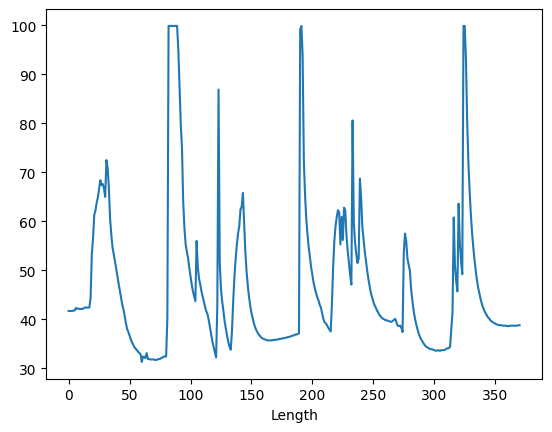

length of data total (training + testing) =  371


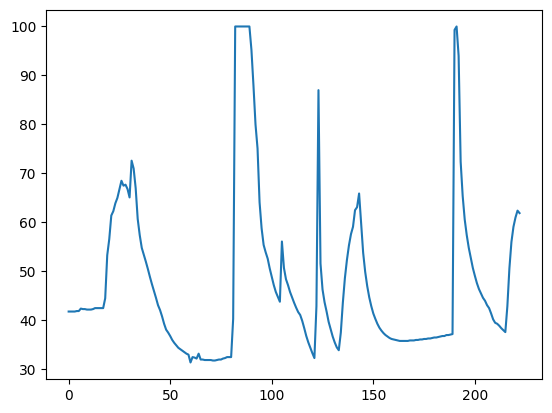

length of data for training =  223


In [94]:
SENSOR_DATA_TOTAL = np.array(SENSOR_DATA_PD.Humi)
#SENSOR_DATA_TOTAL = np.resize(SENSOR_DATA_TOTAL, 500)
SENSOR_DATA_TOTAL = np.resize(SENSOR_DATA_TOTAL, 371)


plt.plot(SENSOR_DATA_TOTAL)

plt.xlabel('Length')
plt.show()
print('length of data total (training + testing) = ',len(SENSOR_DATA_TOTAL))

SENSOR_DATA = SENSOR_DATA_TOTAL[:round(len(SENSOR_DATA_TOTAL)*0.6)]

plt.plot(SENSOR_DATA)
plt.show()

print('length of data for training = ',len(SENSOR_DATA))


In [95]:
def interp_linear(x, y):
    '''Linear interpolation'''
    res = []
    for i in range(1, len(x)):
        slope = (y[i] - y[i - 1]) / (x[i] - x[i - 1])
        l = y[i] - slope * x[i]
        res.extend([slope * x_betw + l for x_betw in range(x[i - 1], x[i])])
    res.append(y[-1])
    return np.array(res)

In [96]:
def interp_quadratic(x, y):
    '''Quadratic interpolation'''
    if len(x) == 2:
        print('Use linear interpolation instead of polinomial when number of samples equals 2')
        return interp_linear(x, y)
    a = ((y[2] - y[0]) / ((x[2] - x[0]) * (x[2] - x[1])) - 
             (y[1] - y[0]) / ((x[1] - x[0]) * (x[2] - x[1])))
    b = (a * (x[0] ** 2 - x[1] ** 2) + y[1] - y[0]) / (x[1] - x[0])
    c = y[0] - a * x[0] ** 2 - b * x[0]
    res = [a * x_betw ** 2 + b * x_betw + c for x_betw in range(x[0], x[2])]
    for i in range(1, len(x) - 2):
        a = ((y[i + 2] - y[i]) / ((x[i + 2] - x[i]) * (x[i + 2] - x[i + 1])) - 
             (y[i + 1] - y[i]) / ((x[i + 1] - x[i]) * (x[i + 2] - x[i + 1])))
        b = (a * (x[i] ** 2 - x[i + 1] ** 2) + y[i + 1] - y[i]) / (x[i + 1] - x[i])
        c = y[i] - a * x[i] ** 2 - b * x[i]
        res.extend([a * x_betw ** 2 + b * x_betw + c for x_betw in range(x[i + 1], x[i + 2])])  
    res.append(y[-1])
    return np.array(res)

In [97]:
def cor(f, g):
    '''Correlation function that you provide'''
    return 100 * np.dot(f, g) / (math.sqrt(np.dot(f, f)) * math.sqrt(np.dot(g, g)))

In [98]:
#chekc this article for MAAPE "A new metric of absolute percentage error for intermittent demand forecasts"
def MAAPE(f,g):
    EPSILON = 1e-10
    return np.mean(np.arctan(np.abs((f - g) / (f + EPSILON)))) * 100
     

In [99]:
other = (SENSOR_DATA, INTERPOLATION_METHOD, SIMILARITY_METHOD, SIMILARITY_THRESHOLD)

In [100]:
def measure(params, *other):                                                        
    '''Returns the number of measurements for certain K and C'''         #.........  params means k and c same number?
    data, interpolation, error, min_sim = other         #...........#############......what is this? how to use it?
    K, C = params                                      #...........#############
    prev_meas = 0
    new_meas = max(1, int(round(K)))
    measurements = []
    days = []
    while new_meas < len(data):
        slope = abs((data[new_meas] - data[prev_meas])) / (new_meas - prev_meas) #prev_meas and new_meas are used as an index (days)
        measurements.append(data[prev_meas])                                   
        days.append(prev_meas)                                             
        prev_meas, new_meas = new_meas, new_meas + max(1, int(round(K - C * slope)))
    measurements.append(data[prev_meas])
    days.append(prev_meas)
    num_of_meas = len(days)
    if prev_meas != len(data) - 1:                        # to include the last measurement, in case the last point from DSRA is not the last point of the oriognal data (to include the last measurements  even it is no considered)
        measurements.append(data[-1])
        days.append(len(data) - 1)
        
    if interpolation == 'linear':
        interp_sampl = interp_linear(days, measurements)
    else:
        interp_sampl = interp_quadratic(days, measurements)
    
    if error == 'correlation':
        similarity = cor(data, interp_sampl)
    else:
        similarity = MAAPE(data, interp_sampl)
        
        # IF WE USE ERROR = correlation THEN "similarity <= min_sim" this has to be adjusted to the opposite IN ALL OF THE CODES
        

    return num_of_meas if similarity <= min_sim else len(SENSOR_DATA)  #.... to return len of data (i.e. 780) incase less than 99.97, is that correct?

In [101]:
def plot2d(data, range_k, range_c, min_sim=SIMILARITY_THRESHOLD, interpolation=INTERPOLATION_METHOD, error=SIMILARITY_METHOD):
    '''Plots the graph of the dependence the number of measurements on K and C'''  
    z = []                                                                         #elaborate on the figure
    x = []
    y = []
    for k in range_k:
        for c in range_c:
            prev_meas = 0
            new_meas = max(1, int(round(k)))
            measurements = []
            days = []
            while new_meas < len(data):
                slope = abs((data[new_meas] - data[prev_meas])) / (new_meas - prev_meas)
                measurements.append(data[prev_meas])
                days.append(prev_meas)
                prev_meas, new_meas = new_meas, new_meas + max(1, int(round(k - c * slope))) # to use it in precise applications, e.g.ADC, maybe change the 1 to clock speed, so the decision of the next measurements isnot a time value that the microcontroller can not perform . also the roun, maybe you can put the number of digit that the microcontroller can catch  
            measurements.append(data[prev_meas])
            days.append(prev_meas)
            num_of_meas = len(days)
            if prev_meas != len(data) - 1:                     # to onclude the last measurement, even it is no considered
                measurements.append(data[-1])
                days.append(len(data) - 1)

            if interpolation == 'linear':
                interp_sampl = interp_linear(days, measurements)
            else:
                interp_sampl = interp_quadratic(days, measurements)
            
            similarity = MAAPE(data, interp_sampl)
            
            if similarity <= min_sim:
                z.append(len(days))
                x.append(k)
                y.append(c)
    minz = min(z)
    opti = []
    for j in range (len(z)):
        if minz == z[j]:
            opti.append(z[j])
            opti.append(x[j])
            opti.append(y[j])
            break

    return opti

In [102]:
def PLOT(data, K, C, original_signal=True, interpolation=INTERPOLATION_METHOD, error=SIMILARITY_METHOD):
    '''Plots groundtruth and measured with optimized sampling sensor signal'''
    prev_meas = 0
    new_meas = max(1, int(round(K))) # why to code as int()
    measurements = []
    days = []
    while new_meas < len(data):
        slope = abs((data[new_meas] - data[prev_meas])) / (new_meas - prev_meas)
        measurements.append(data[prev_meas])
        days.append(prev_meas)
        prev_meas, new_meas = new_meas, new_meas + max(1, int(round(K - C * slope)))  # to use it in precise applications, e.g.ADC, maybe change the 1 to clock speed, so the decision of the next measurements isnot a time value that the microcontroller can not perform . also the roun, maybe you can put the number of digit that the microcontroller can catch  
    measurements.append(data[prev_meas])
    days.append(prev_meas)
    num_of_meas = len(days)
    if prev_meas != len(data) - 1:
        measurements.append(data[-1])
        days.append(len(data) - 1)
    
    if interpolation == 'linear':
        plotList = interp_linear(days, measurements)
    else:
        plotList = interp_quadratic(days, measurements)
    
    similarity = MAAPE(data, plotList)   #cor(data, plotList)
    sampling_reduced = abs((round(len(days)/len(SENSOR_DATA),2 )*100)-100)
    
    return similarity, plotList, measurements, days, sampling_reduced

In [103]:
def reconstruction(data, K, C):
    current_TBM = 42
    prev_TBM = 1
    reconstructed = []
    for i in range (len(data)):
        if i == 0:
            current_TBM = 1
            prev_TBM = current_TBM
        else :
            current_TBM = max(1, K - abs(C * (data[i] - data[i - 1]) / prev_TBM))

            prev_TBM = current_TBM
            current_TBM = round(current_TBM)
            nb_values = current_TBM // 1
            diff = data[i] - data[i - 1]

            if diff == 0:
                for _ in range (1, nb_values):
                    reconstructed.append(data[i])
            else :
                interv = diff / (nb_values)
                for k in range (1, nb_values):
                    reconstructed.append(data[i - 1] + k * interv)
        
        reconstructed.append(data[i])

    return reconstructed

In [104]:
def my_resize(reconstruct, original_size):
    diff = len(reconstruct) - original_size
    if diff <= 0 and diff > -500 :
        for _ in range (-diff) :
            reconstruct.append(reconstruct[-1])
        return reconstruct
    elif diff >= 500 or diff < -500:
        print("Resize will not be precise, try to change the error threshold.")
        return reconstruct
    return np.resize(reconstruct, original_size)

In [105]:
import time

#please find your bounds

start_time = time.perf_counter()  # Record the starting time
#please find your bounds

# These arrays will contain the important values of the cross validation
cross_valid_train = []
cross_valid_test = []


# Initial/Default values of the ranges
rangeK = 0, 30, 2
rangeC = 0, 450, 10

# Just for the pretty print
test_nb = 0

# Has to be set as it is in the while condition

cz = 10



while cz > 1:
    kx, ky, kz = rangeK
    cx, cy, cz = rangeC

    # Trouver les valeurs optimales avec plot2d
    optimal_values = plot2d(SENSOR_DATA, range(kx, ky, kz), range(cx, cy, cz)) # Retourne les valeurs optimales

    # Enregistre les résultats (en supposant que plot2d retourne K et C en [1] et [2])
    cross_valid_train.append([test_nb, optimal_values[1], optimal_values[2]])  # Ajoute les valeurs optimales pour le training
    cross_valid_test.append([test_nb, optimal_values[1], optimal_values[2]])   # Ajoute les valeurs optimales pour le test

    # Ajuster les plages de valeurs de K et C
    kx, ky, kz = round((optimal_values[1] + kx) / 2) - 4, round((optimal_values[1] + ky)) + 4, max(1, round(kz / 2))
    cx, cy, cz = round((optimal_values[2] + cx) / 2) - 4, round((optimal_values[2] + cy)) + 4, max(1, round(cz / 2))

    # Mettre à jour rangeK et rangeC pour la prochaine itération
    rangeK = kx, ky, kz
    rangeC = cx, cy, cz
    test_nb += 1


# Optimization DSA

# Set the bounds around the last optimal value
bounds = [(optimal_values[1] - 2, optimal_values[1] + 2), (optimal_values[2] - 2, optimal_values[2] + 2)]

# Same as before to find the best values for K and C
resdual = dual_annealing(measure, bounds, args=other, maxiter=900)
K, C = resdual.x


# Store the values of K, C, error, sampling reduced and a message 
SENSOR_DATA = SENSOR_DATA_TOTAL
# Same but with test data
error_test, plotList, data, days, sampling_reduced = PLOT(SENSOR_DATA_TOTAL, K, C)
plt.close()

# Catching the interesting values from the original data
inter_data = []
data = np.asarray(data, float)
for k in range (len(days)):
    inter_data.append(plotList[days[k]])

# Reconstruction of the data
reconstructed = my_resize(reconstruction(inter_data, K, C), len(SENSOR_DATA_TOTAL))

print(f"Test for {SIMILARITY_THRESHOLD}, K : {K}, C : {C}, SR : {sampling_reduced}")



end_time = time.perf_counter()  # Record the ending time

# Calculate the time taken for the optimization in seconds
time_taken = end_time - start_time

# Convert time to minutes with two decimal places
time_min = time_taken / 60

#plt.show() 

# Print the time taken in minutes with two decimal places
print(f'Time taken to do the cross validation : {time_min:.2f} minutes')
plt.close()

Test for 2, K : 3.553298575378414, C : 0.15039656832157888, SR : 68.0
Time taken to do the cross validation : 0.11 minutes


In [106]:
average_K = 0
average_C = 0
length_test = len(cross_valid_test)
nb_value = len(cross_valid_train) + len(cross_valid_test)
for j in range (length_test):
    average_K += (cross_valid_train[j][1] + cross_valid_test[j][1]) / nb_value
    average_C += (cross_valid_train[j][2] + cross_valid_test[j][2])/nb_value

print(average_K, average_C)
print("Taille de cross_valid_train:", len(cross_valid_train))
print("Taille de cross_valid_test:", len(cross_valid_test))


2.6666666666666665 0.3333333333333333
Taille de cross_valid_train: 3
Taille de cross_valid_test: 3


In [107]:
# Initialise KFold avec le nombre de splits souhaité, par exemple 5
kfold = KFold(n_splits=2)

# Test every K, C for every split possible
test_k_c = []

for i in range(length_test):
    temporary_stock = []

    # Utiliser l'instance kfold pour faire le split
    for train, test in kfold.split(SENSOR_DATA):  # Utiliser 'kfold' ici

        tmp_k, tmp_c = cross_valid_train[i][1], cross_valid_train[i][2]  # Utilise 'i' pour accéder aux valeurs

        # Plot sur les données d'entraînement
        error, _, _, _, sampling_reduced = PLOT(SENSOR_DATA[train], tmp_k, tmp_c)
        plt.close()
        
        # Plot sur les données de test
        error_test, _, _, _, samp_reduced_test = PLOT(SENSOR_DATA[test], tmp_k, tmp_c)
        plt.close()

        temporary_stock.append(["Train :", error, sampling_reduced, "Test :", error_test, samp_reduced_test])

    test_k_c.append(temporary_stock)

# Afficher les résultats
for j in range(len(test_k_c)):
    print(f"{j} : {test_k_c[j]} \n")


0 : [['Train :', np.float64(1.8103776161536966), 75.0, 'Test :', np.float64(1.108086901535799), 75.0], ['Train :', np.float64(1.108086901535799), 75.0, 'Test :', np.float64(1.8103776161536966), 75.0]] 

1 : [['Train :', np.float64(2.91457095136741), 80.0, 'Test :', np.float64(1.089930518277132), 80.0], ['Train :', np.float64(1.089930518277132), 80.0, 'Test :', np.float64(2.91457095136741), 80.0]] 

2 : [['Train :', np.float64(1.8103776161536966), 75.0, 'Test :', np.float64(1.108086901535799), 75.0], ['Train :', np.float64(1.108086901535799), 75.0, 'Test :', np.float64(1.8103776161536966), 75.0]] 



In [108]:
# errorr, _, _, _, sr = PLOT(SENSOR_DATA, average_K, average_C)
E_as_general = 3.6769928411840525
S_as_general = 0.25145172729610366
errorr, _, _, _, sr = PLOT(SENSOR_DATA, E_as_general, S_as_general)

print("Error in %:",errorr,"\n Sampling reduction in %: ", sr)
plt.close()

Error in %: 2.0406800973607626 
 Sampling reduction in %:  69.0
